In [1]:
from google.colab import drive
drive.mount('/content/drive')

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("/content/drive/MyDrive/london-crime-analysis/data/cleaned_crime_data.csv")

# Convert Month back to datetime
df['Month'] = pd.to_datetime(df['Month'])

print(f"Rows: {len(df):,}")
print(df.head())

Mounted at /content/drive
Rows: 1,125,295
       Month  Longitude   Latitude                    Location  LSOA code  \
0 2023-04-01   0.136416  51.584898  On or near Lawn Farm Grove  E01000027   
1 2023-04-01   0.142112  51.589389            On or near A1112  E01000027   
2 2023-04-01   0.140194  51.582356      On or near Hatch Grove  E01000027   
3 2023-04-01   0.142112  51.589389            On or near A1112  E01000027   
4 2023-04-01   0.140127  51.588913  On or near Beansland Grove  E01000027   

                   LSOA name             Crime type  \
0  Barking and Dagenham 001A           Public order   
1  Barking and Dagenham 001A  Anti-social behaviour   
2  Barking and Dagenham 001A  Anti-social behaviour   
3  Barking and Dagenham 001A  Anti-social behaviour   
4  Barking and Dagenham 001A  Anti-social behaviour   

         Last outcome category               Borough  
0  Unable to prosecute suspect  Barking and Dagenham  
1                 Not recorded  Barking and Dagenham  

In [2]:
# Extract borough name from LSOA name
# LSOA name format is always "Borough Name 001A" - borough is everything before the last word
df['Borough'] = df['LSOA name'].str.rsplit(' ', n=1).str[0]

# How many unique boroughs do we have?
print(f"Total unique boroughs/areas: {df['Borough'].nunique()}")
print("\nAll unique values:")
print(sorted(df['Borough'].unique()))

Total unique boroughs/areas: 315

All unique values:
['Adur', 'Allerdale', 'Arun', 'Ashfield', 'Ashford', 'Aylesbury Vale', 'Babergh', 'Barking and Dagenham', 'Barnet', 'Barnsley', 'Barrow-in-Furness', 'Basildon', 'Basingstoke and Deane', 'Bassetlaw', 'Bath and North East Somerset', 'Bedford', 'Bexley', 'Birmingham', 'Blaby', 'Blackburn with Darwen', 'Blackpool', 'Blaenau Gwent', 'Bolsover', 'Bolton', 'Boston', 'Bournemouth, Christchurch and Poole', 'Bracknell Forest', 'Bradford', 'Braintree', 'Breckland', 'Brent', 'Brentwood', 'Bridgend', 'Brighton and Hove', 'Bristol', 'Broadland', 'Bromley', 'Broxbourne', 'Broxtowe', 'Buckinghamshire', 'Burnley', 'Bury', 'Calderdale', 'Cambridge', 'Camden', 'Cannock Chase', 'Canterbury', 'Cardiff', 'Carlisle', 'Carmarthenshire', 'Castle Point', 'Central Bedfordshire', 'Ceredigion', 'Charnwood', 'Chelmsford', 'Cheltenham', 'Cherwell', 'Cheshire East', 'Cheshire West and Chester', 'Chesterfield', 'Chichester', 'Chorley', 'City of London', 'Colchester'

In [3]:
london_boroughs = [
    'Barking and Dagenham', 'Barnet', 'Bexley', 'Brent', 'Bromley',
    'Camden', 'City of London', 'Croydon', 'Ealing', 'Enfield',
    'Greenwich', 'Hackney', 'Hammersmith and Fulham', 'Haringey',
    'Harrow', 'Havering', 'Hillingdon', 'Hounslow', 'Islington',
    'Kensington and Chelsea', 'Kingston upon Thames', 'Lambeth',
    'Lewisham', 'Merton', 'Newham', 'Redbridge', 'Richmond upon Thames',
    'Southwark', 'Sutton', 'Tower Hamlets', 'Waltham Forest',
    'Wandsworth', 'Westminster'
]

df = df[df['Borough'].isin(london_boroughs)]

print(f"Rows after filtering to London: {len(df):,}")
print(f"Unique boroughs: {df['Borough'].nunique()}")
print(sorted(df['Borough'].unique()))

Rows after filtering to London: 1,125,295
Unique boroughs: 33
['Barking and Dagenham', 'Barnet', 'Bexley', 'Brent', 'Bromley', 'Camden', 'City of London', 'Croydon', 'Ealing', 'Enfield', 'Greenwich', 'Hackney', 'Hammersmith and Fulham', 'Haringey', 'Harrow', 'Havering', 'Hillingdon', 'Hounslow', 'Islington', 'Kensington and Chelsea', 'Kingston upon Thames', 'Lambeth', 'Lewisham', 'Merton', 'Newham', 'Redbridge', 'Richmond upon Thames', 'Southwark', 'Sutton', 'Tower Hamlets', 'Waltham Forest', 'Wandsworth', 'Westminster']


In [4]:
# Drop columns that add no value - both just say 'Metropolitan Police Service'
df.drop(columns=['Reported by', 'Falls within'], inplace=True)

# Save the updated cleaned file
df.to_csv("/content/drive/MyDrive/london-crime-analysis/data/cleaned_crime_data.csv", index=False)

print(f"Final dataset: {len(df):,} rows, {len(df.columns)} columns")
print(f"Columns remaining: {df.columns.tolist()}")

Final dataset: 1,125,295 rows, 9 columns
Columns remaining: ['Month', 'Longitude', 'Latitude', 'Location', 'LSOA code', 'LSOA name', 'Crime type', 'Last outcome category', 'Borough']


# **EDA Q1 - Which crime types are most common in London?**

/tmp/ipykernel_29817/3459750695.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=crime_counts.values, y=crime_counts.index, palette='viridis')


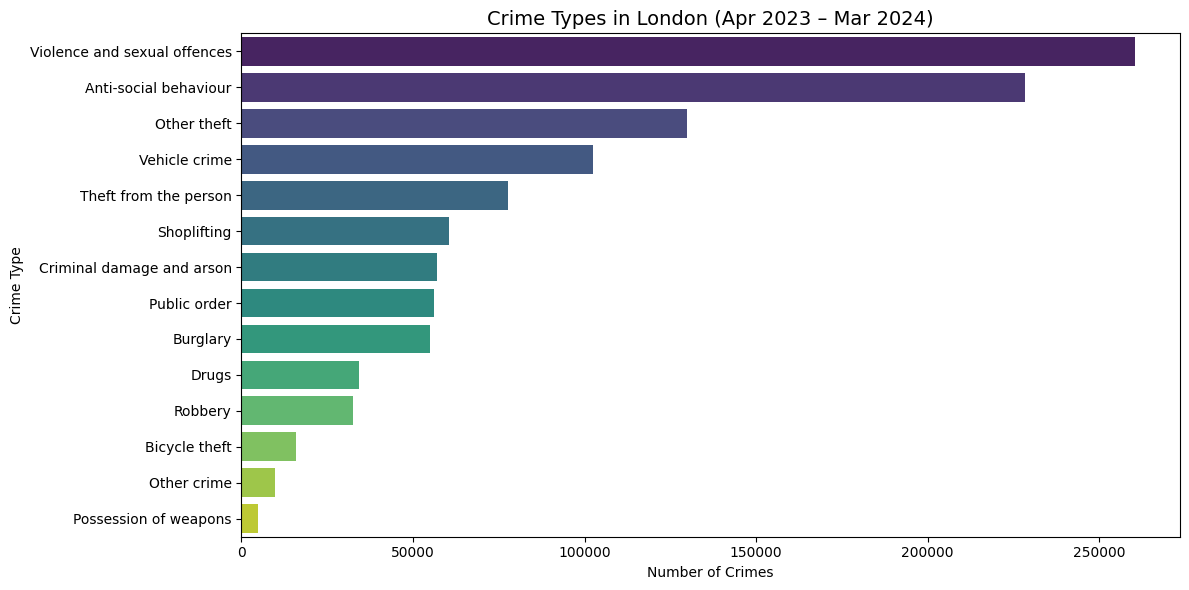

Crime type
Violence and sexual offences    260509
Anti-social behaviour           228504
Other theft                     129944
Vehicle crime                   102353
Theft from the person            77731
Shoplifting                      60368
Criminal damage and arson        57100
Public order                     56259
Burglary                         54930
Drugs                            34386
Robbery                          32527
Bicycle theft                    15970
Other crime                       9860
Possession of weapons             4854
Name: count, dtype: int64


In [5]:
# Count crimes by type and sort
crime_counts = df['Crime type'].value_counts()

# Plot
plt.figure(figsize=(12, 6))
sns.barplot(x=crime_counts.values, y=crime_counts.index, palette='viridis')
plt.title('Crime Types in London (Apr 2023 – Mar 2024)', fontsize=14)
plt.xlabel('Number of Crimes')
plt.ylabel('Crime Type')
plt.tight_layout()
plt.savefig("/content/drive/MyDrive/london-crime-analysis/data/chart1_crime_types.png", dpi=150)
plt.show()

print(crime_counts)

Violence and sexual offences is the most common crime type in London (260,509 incidents), followed by Anti-social behaviour (228,504) and Other theft (129,944). Together these three categories account for over half of all recorded crime. At the other end, Possession of weapons (4,854) and Other crime (9,860) are the least frequent. Notably, Shoplifting (60,368) and Theft from the person (77,731) are both significant — reflecting the high footfall of a major city.

# **Q2 - How does crime volume change month by month?**

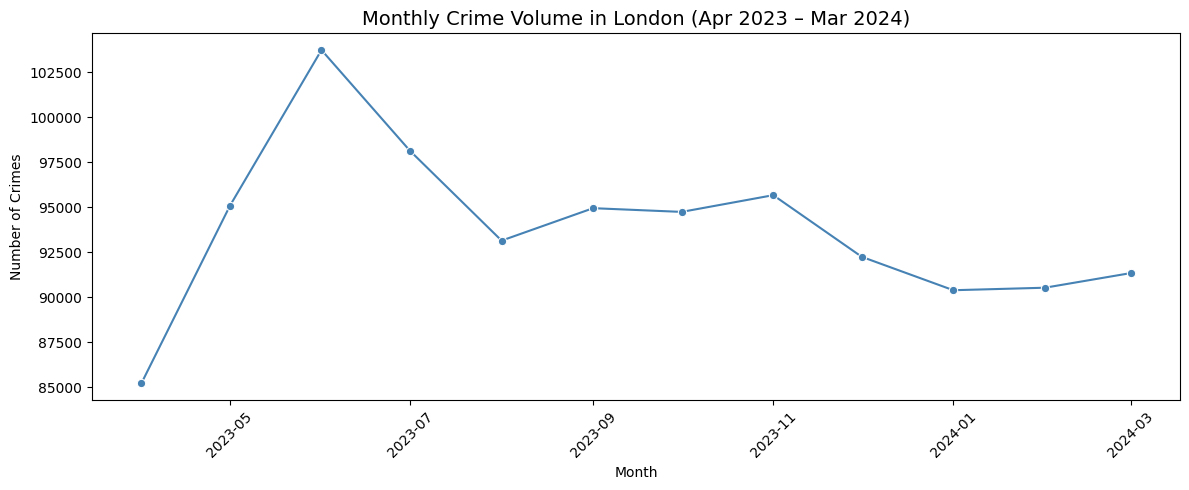

        Month  Crime Count
0  2023-04-01        85220
1  2023-05-01        95094
2  2023-06-01       103750
3  2023-07-01        98143
4  2023-08-01        93156
5  2023-09-01        94959
6  2023-10-01        94752
7  2023-11-01        95682
8  2023-12-01        92253
9  2024-01-01        90399
10 2024-02-01        90538
11 2024-03-01        91349


In [3]:
monthly_counts = df.groupby('Month').size().reset_index(name='Crime Count')

plt.figure(figsize=(12, 5))
sns.lineplot(data=monthly_counts, x='Month', y='Crime Count', marker='o', color='steelblue')
plt.title('Monthly Crime Volume in London (Apr 2023 – Mar 2024)', fontsize=14)
plt.xlabel('Month')
plt.ylabel('Number of Crimes')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("/content/drive/MyDrive/london-crime-analysis/data/chart2_monthly_trend.png", dpi=150)
plt.show()

print(monthly_counts)

# **Q3 - Which boroughs have the highest crime counts?**

/tmp/ipykernel_738/3731709217.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


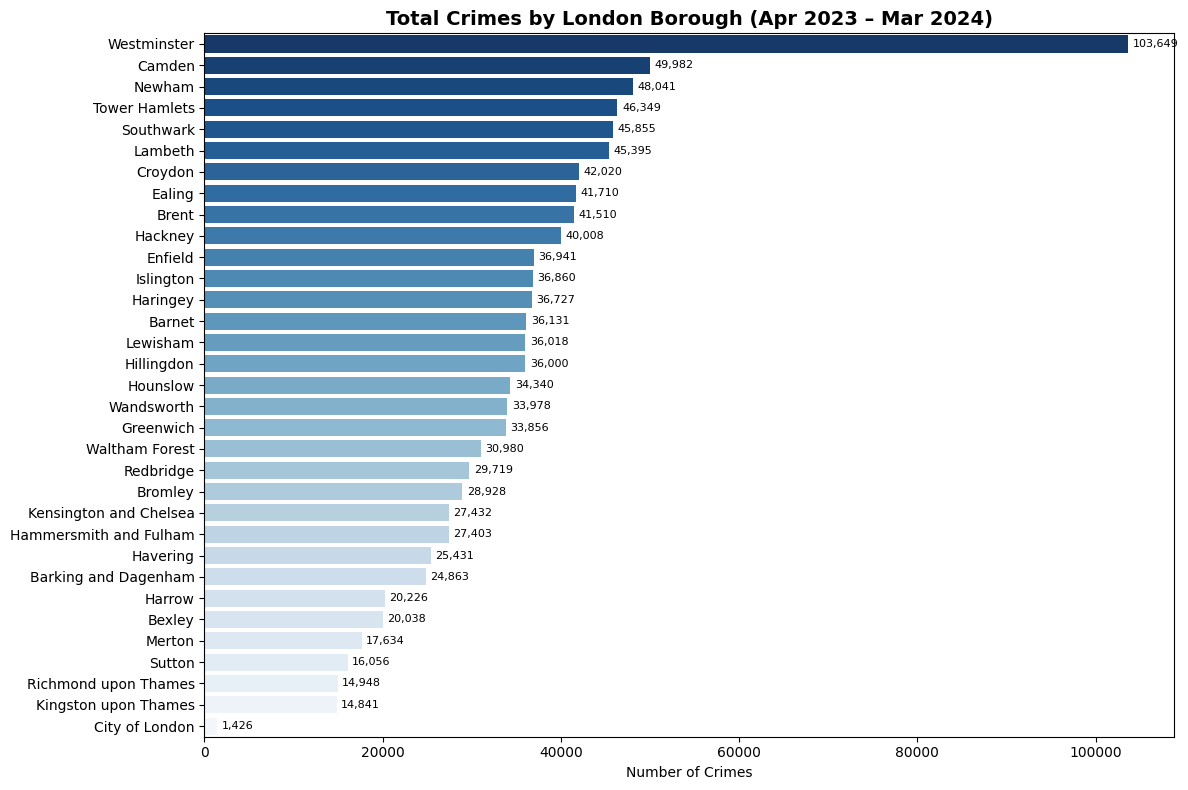


Top 5 boroughs:
          Borough  Crime Count
32    Westminster       103649
5          Camden        49982
24         Newham        48041
29  Tower Hamlets        46349
27      Southwark        45855

Bottom 5 boroughs:
                 Borough  Crime Count
23                Merton        17634
28                Sutton        16056
26  Richmond upon Thames        14948
20  Kingston upon Thames        14841
6         City of London         1426


In [4]:
# Crime by Borough
import matplotlib.pyplot as plt
import seaborn as sns

borough_counts = (
    df.groupby('Borough')
      .size()
      .reset_index(name='Crime Count')
      .sort_values('Crime Count', ascending=False)
)

fig, ax = plt.subplots(figsize=(12, 8))

sns.barplot(
    data=borough_counts,
    x='Crime Count',
    y='Borough',
    palette='Blues_r',
    ax=ax
)

ax.set_title('Total Crimes by London Borough (Apr 2023 – Mar 2024)', fontsize=14, fontweight='bold')
ax.set_xlabel('Number of Crimes')
ax.set_ylabel('')

# Add value labels on each bar
for i, (val, name) in enumerate(zip(borough_counts['Crime Count'], borough_counts['Borough'])):
    ax.text(val + 500, i, f'{val:,}', va='center', fontsize=8)

plt.tight_layout()
plt.savefig('borough_crime_counts.png', dpi=150)
plt.show()

print("\nTop 5 boroughs:")
print(borough_counts.head())
print("\nBottom 5 boroughs:")
print(borough_counts.tail())

Westminster stands out as a dramatic outlier, recording 103,649 crimes — more than double the second-highest borough, Camden (49,982). This is consistent with Westminster being the most visited area in London, encompassing Oxford Street, Soho, Covent Garden, and major transport hubs, all of which generate high footfall and therefore higher crime exposure. Camden, Newham, Tower Hamlets, and Southwark round out the top 5, all inner-London boroughs with dense populations and busy night-time economies.
At the other end, the bottom 5 are all outer South and Southwest London suburbs — Merton, Sutton, Richmond upon Thames, and Kingston upon Thames — which are more residential in character with significantly lower footfall. Their crime counts (14,000–17,000) are roughly 6–7 times lower than Westminster's.
The most interesting outlier at the bottom is the City of London, with just 1,426 crimes. This is not a data error — the City of London is a tiny, roughly 1-square-mile financial district with a very small residential population. Most activity there is weekday office work, which naturally suppresses certain crime types like anti-social behaviour and residential burglary.


# **Q4 - What proportion of crimes get resolved?**

          Outcome Group   Count  Percentage
0     No Further Action  707356        62.9
1  Other / Not Recorded  332037        29.5
2   Unable to Prosecute   81124         7.2
3              Resolved    3454         0.3
4   Under Investigation    1324         0.1


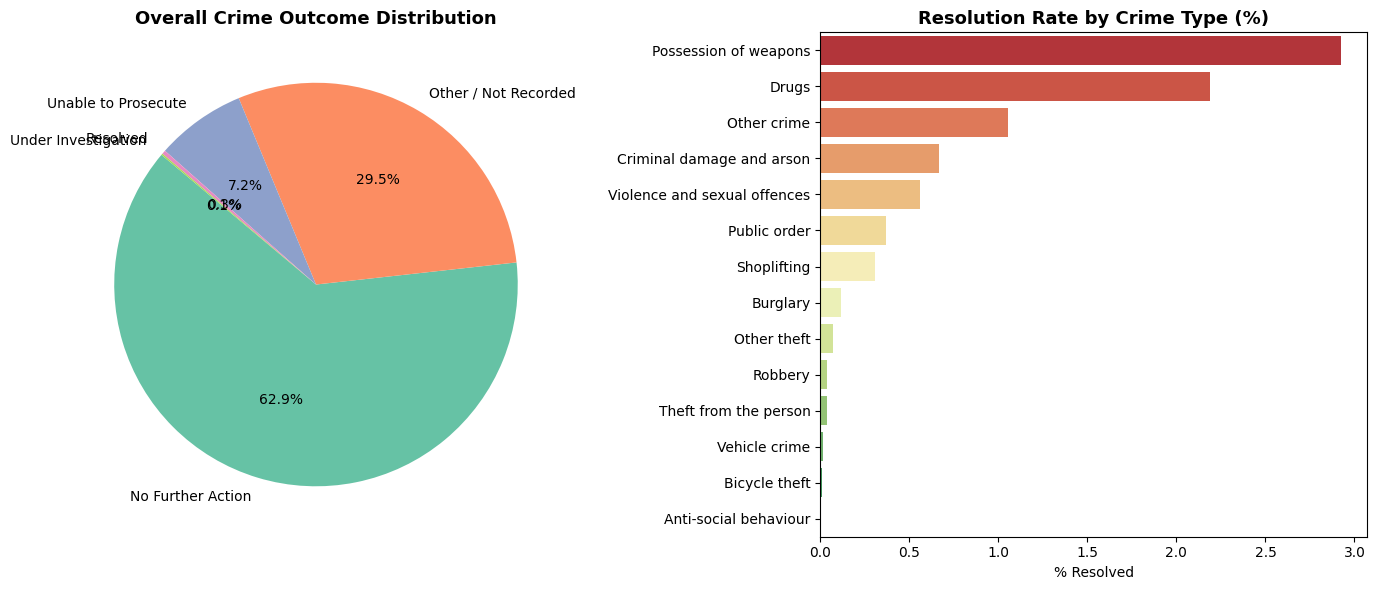

In [37]:
#  Q4: Resolution / Outcome Rates

# Group outcomes into meaningful buckets
def categorise_outcome(outcome):
    resolved = [
        'Offender given a caution',
        'Suspect charged as part of another case',
        'Offender given a penalty notice',
        'Offender given community sentence',
        'Offender given suspended prison sentence',
        'Offender sent to prison',
        'Offender fined',
        'Offender deprived of property',
        'Offender given absolute discharge',
        'Offender otherwise dealt with',
        'Suspect charged'
    ]
    if any(r.lower() in outcome.lower() for r in resolved):
        return 'Resolved'
    elif 'investigation complete' in outcome.lower():
        return 'No Further Action'
    elif 'unable to prosecute' in outcome.lower():
        return 'Unable to Prosecute'
    elif 'under investigation' in outcome.lower() or 'awaiting' in outcome.lower():
        return 'Under Investigation'
    else:
        return 'Other / Not Recorded'

df['Outcome Group'] = df['Last outcome category'].apply(categorise_outcome)

outcome_summary = (
    df['Outcome Group']
      .value_counts()
      .reset_index()
)
outcome_summary.columns = ['Outcome Group', 'Count']
outcome_summary['Percentage'] = (outcome_summary['Count'] / len(df) * 100).round(1)

print(outcome_summary)

# ── Pie chart ──
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Pie
axes[0].pie(
    outcome_summary['Count'],
    labels=outcome_summary['Outcome Group'],
    autopct='%1.1f%%',
    colors=sns.color_palette('Set2', len(outcome_summary)),
    startangle=140
)
axes[0].set_title('Overall Crime Outcome Distribution', fontsize=13, fontweight='bold')

# Resolution rate by top crime types
resolution_by_crime = (
    df.groupby('Crime type')['Outcome Group']
      .apply(lambda x: (x == 'Resolved').sum() / len(x) * 100)
      .reset_index()
)
resolution_by_crime.columns = ['Crime Type', 'Resolution Rate (%)']
resolution_by_crime = resolution_by_crime.sort_values('Resolution Rate (%)', ascending=False)

sns.barplot(
    data=resolution_by_crime,
    x='Resolution Rate (%)',
    y='Crime Type',
    palette='RdYlGn',
    ax=axes[1]
)
axes[1].set_title('Resolution Rate by Crime Type (%)', fontsize=13, fontweight='bold')
axes[1].set_xlabel('% Resolved')
axes[1].set_ylabel('')

plt.tight_layout()
plt.savefig('outcome_analysis.png', dpi=150)
plt.show()

Less than 1% of London crimes recorded between April 2023 and March 2024 resulted in any legal action against an offender. This raises fundamental questions about resource allocation, reporting incentives, and what 'recorded crime' actually represents in policing terms.

# **Q5 - Are specific crime types rising or falling over time?**

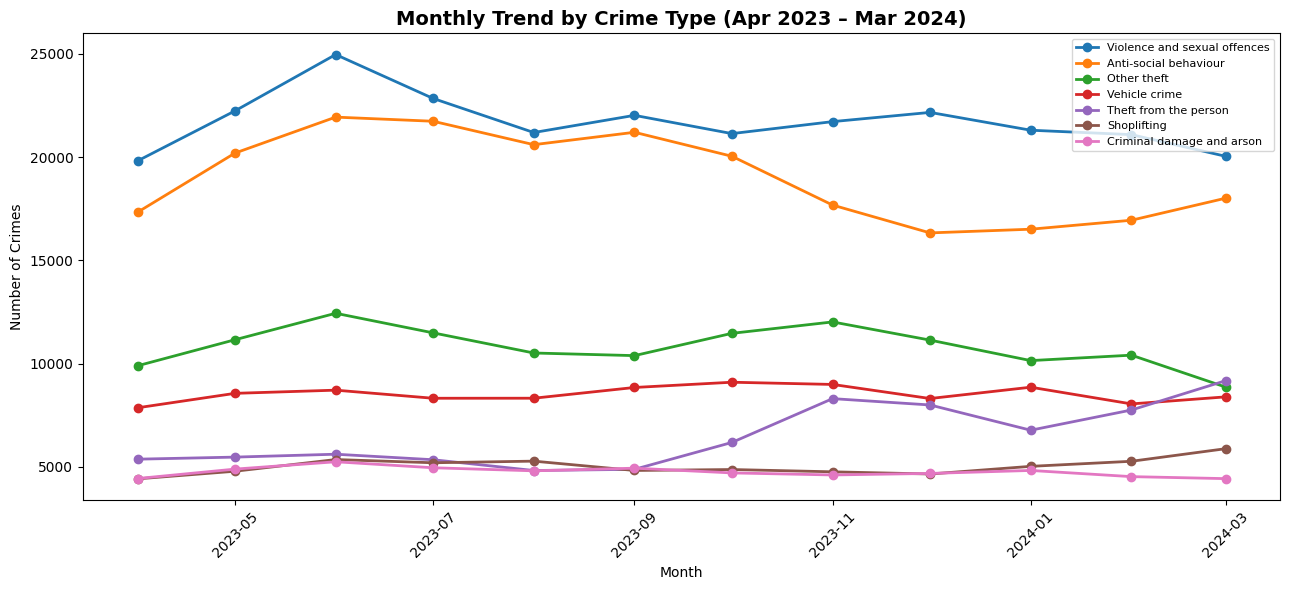

Crime type  Anti-social behaviour  Criminal damage and arson  Other theft  \
Month                                                                       
2023-04-01                  17330                       4439         9897   
2023-05-01                  20194                       4895        11158   
2023-06-01                  21935                       5250        12439   
2023-07-01                  21735                       4960        11491   
2023-08-01                  20601                       4812        10516   
2023-09-01                  21201                       4940        10389   
2023-10-01                  20040                       4711        11468   
2023-11-01                  17677                       4612        12020   
2023-12-01                  16330                       4686        11140   
2024-01-01                  16509                       4830        10148   
2024-02-01                  16943                       4531        10411   

In [10]:
# ── Q5: Monthly Trend by Crime Type ──────────────────────────────────

# Picking top 7 crime types by total volume
top_crimes = df['Crime type'].value_counts().head(7).index.tolist()

monthly_by_crime = (
    df[df['Crime type'].isin(top_crimes)]
      .groupby(['Month', 'Crime type'])
      .size()
      .reset_index(name='Count')
)

fig, ax = plt.subplots(figsize=(13, 6))

for crime in top_crimes:
    subset = monthly_by_crime[monthly_by_crime['Crime type'] == crime]
    ax.plot(subset['Month'], subset['Count'], marker='o', linewidth=2, label=crime)

ax.set_title('Monthly Trend by Crime Type (Apr 2023 – Mar 2024)', fontsize=14, fontweight='bold')
ax.set_xlabel('Month')
ax.set_ylabel('Number of Crimes')
ax.legend(loc='upper right', fontsize=8)
ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig('monthly_trend_by_crime.png', dpi=150)
plt.show()

# Printing the actual numbers
pivot = monthly_by_crime.pivot(index='Month', columns='Crime type', values='Count')
print(pivot)

Several clear patterns emerge across the 12-month period:

- **Anti-social behaviour** peaks sharply in summer (June–July) and drops in winter —
  consistent with warmer months pushing activity outdoors.
- **Violence and sexual offences** follows the same summer peak (June: 24,964),
  likely driven by increased social activity and nighttime economy.
- **Theft from the person** shows the opposite pattern — it rises steadily from October
  through March, peaking at 9,175 in March 2024. Darker evenings, busier public
  transport, and Christmas footfall all contribute.
- **Shoplifting** trends upward across the full year (4,423 in April to 5,883 in March),
  consistent with cost-of-living pressure building across 2023–24.
- **Vehicle crime** remains relatively stable year-round (~8,000–9,000/month),
  suggesting it is opportunity-driven rather than seasonal.

# **Q6 - Which boroughs have the worst resolution rates?**

                   Borough  Resolution Rate (%)
7                  Croydon                 0.50
28                  Sutton                 0.50
16              Hillingdon                 0.49
20    Kingston upon Thames                 0.48
4                  Bromley                 0.45
15                Havering                 0.43
0     Barking and Dagenham                 0.42
24                  Newham                 0.41
2                   Bexley                 0.39
30          Waltham Forest                 0.38
23                  Merton                 0.37
22                Lewisham                 0.36
10               Greenwich                 0.35
9                  Enfield                 0.34
31              Wandsworth                 0.33
13                Haringey                 0.31
25               Redbridge                 0.30
26    Richmond upon Thames                 0.29
29           Tower Hamlets                 0.28
18               Islington              

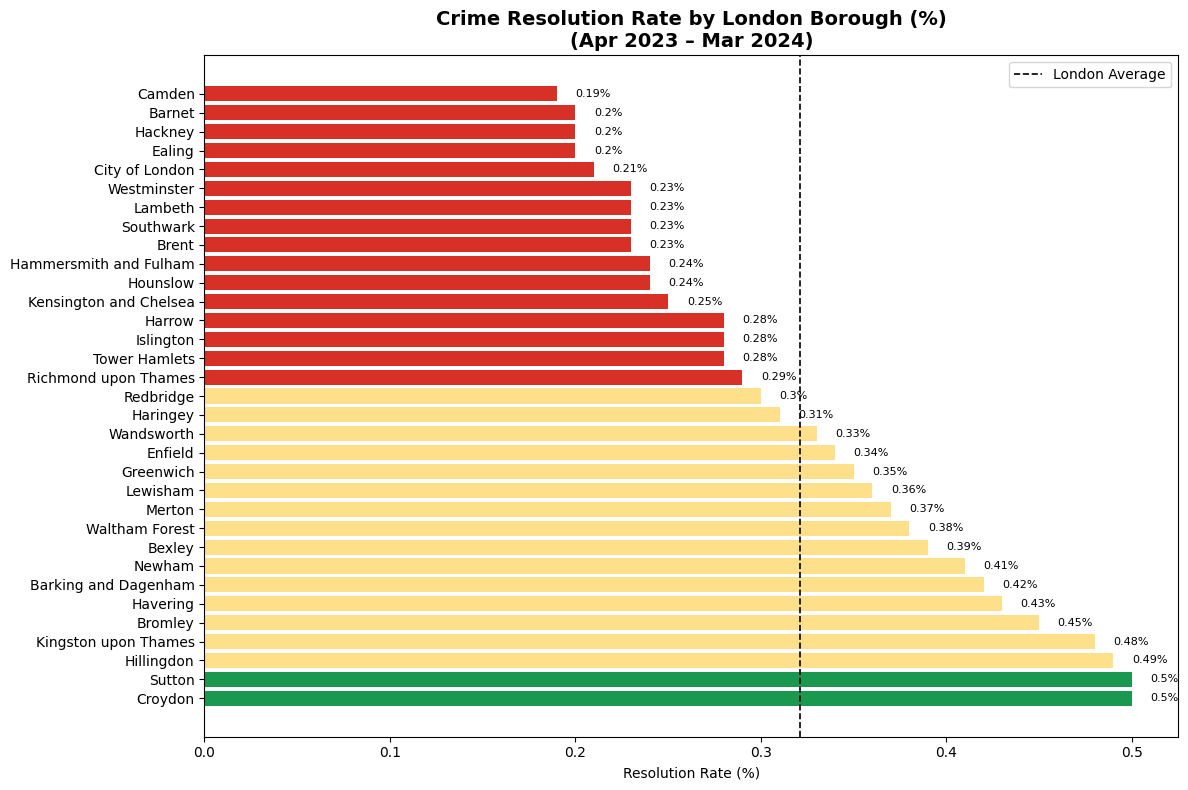


London average resolution rate: 0.32%
Highest: Croydon — 0.50%
Lowest:  Camden — 0.19%


In [11]:
# ── Q6: Resolution Rate by Borough ───────────────────────────────────

borough_resolution = (
    df.groupby('Borough')['Outcome Group']
      .apply(lambda x: round((x == 'Resolved').sum() / len(x) * 100, 2))
      .reset_index()
)
borough_resolution.columns = ['Borough', 'Resolution Rate (%)']
borough_resolution = borough_resolution.sort_values('Resolution Rate (%)', ascending=False)

print(borough_resolution)

# ── Bar chart ──
fig, ax = plt.subplots(figsize=(12, 8))

colors = ['#d73027' if r < 0.3 else '#fee08b' if r < 0.5 else '#1a9850'
          for r in borough_resolution['Resolution Rate (%)']]

ax.barh(borough_resolution['Borough'], borough_resolution['Resolution Rate (%)'],
        color=colors)

ax.set_title('Crime Resolution Rate by London Borough (%)\n(Apr 2023 – Mar 2024)',
             fontsize=14, fontweight='bold')
ax.set_xlabel('Resolution Rate (%)')
ax.set_ylabel('')
ax.axvline(x=borough_resolution['Resolution Rate (%)'].mean(),
           color='black', linestyle='--', linewidth=1.2, label='London Average')
ax.legend()

# Add value labels
for i, val in enumerate(borough_resolution['Resolution Rate (%)']):
    ax.text(val + 0.01, i, f'{val}%', va='center', fontsize=8)

plt.tight_layout()
plt.savefig('borough_resolution_rate.png', dpi=150)
plt.show()

# Summary stats
print(f"\nLondon average resolution rate: {borough_resolution['Resolution Rate (%)'].mean():.2f}%")
print(f"Highest: {borough_resolution.iloc[0]['Borough']} — {borough_resolution.iloc[0]['Resolution Rate (%)']:.2f}%")
print(f"Lowest:  {borough_resolution.iloc[-1]['Borough']} — {borough_resolution.iloc[-1]['Resolution Rate (%)']:.2f}%")

Across all 33 boroughs, the London average resolution rate is just **0.32%** — fewer than
1 in 300 recorded crimes results in any legal action. Croydon records the highest rate
at 0.50%, while Camden sits at the bottom at 0.19%. The variation is narrow, which
itself is telling: this is not a borough-level problem, it is a systemic one.

# **Q7 - Crime Profile Heatmap by Borough**

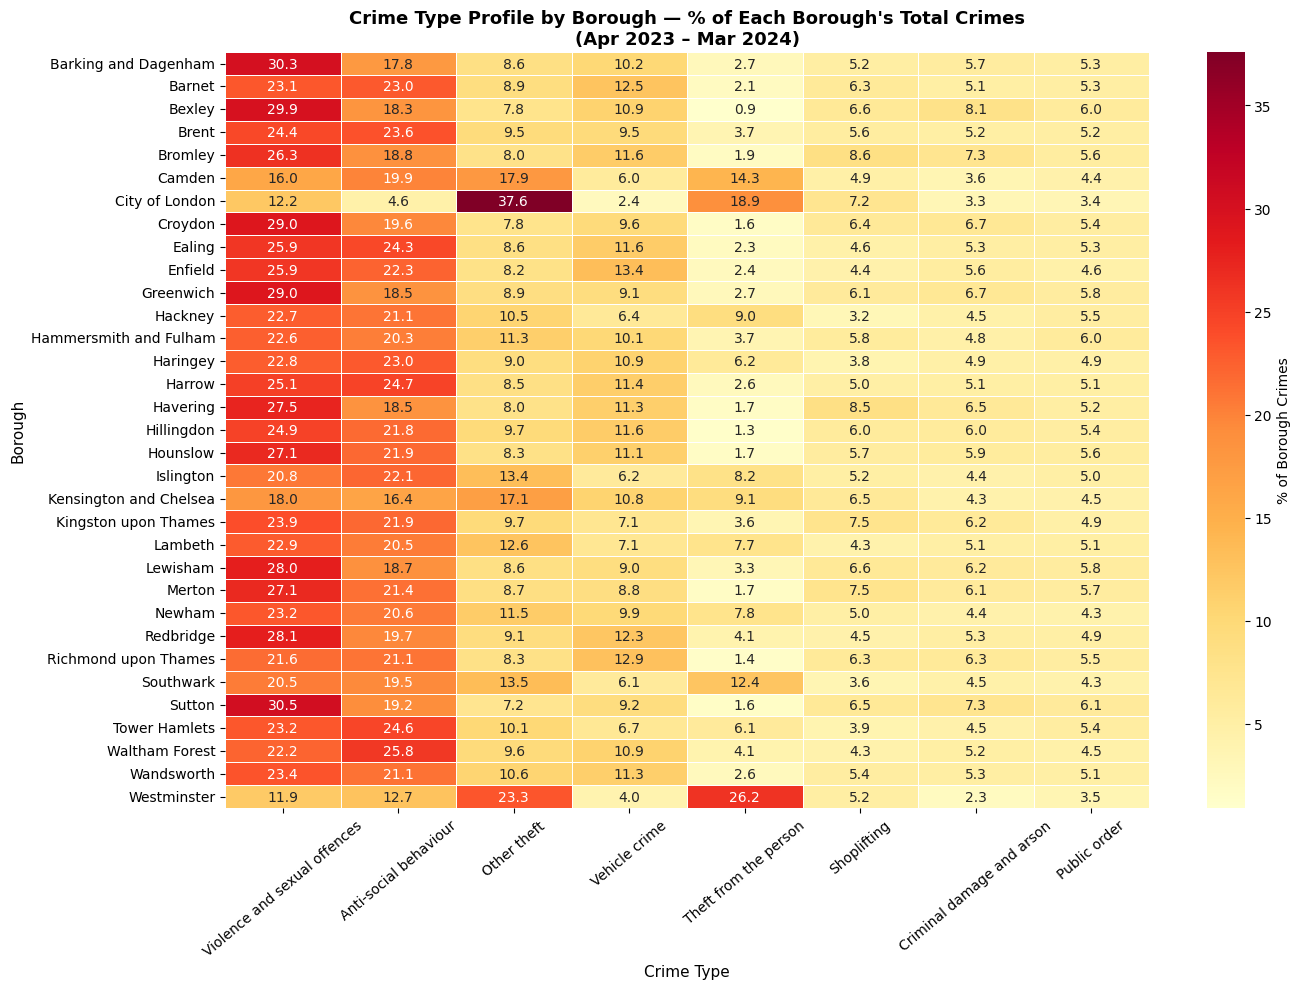


Boroughs with highest Violence & Sexual Offences proportion:
Borough
Sutton                  30.511958
Barking and Dagenham    30.269879
Bexley                  29.938118
Croydon                 29.040933
Greenwich               29.025874
Name: Violence and sexual offences, dtype: float64

Boroughs with highest Anti-social behaviour proportion:
Borough
Waltham Forest    25.839251
Harrow            24.730545
Tower Hamlets     24.641308
Ealing            24.317909
Brent             23.640087
Name: Anti-social behaviour, dtype: float64


In [12]:
# ── Q7: Crime Profile by Borough (proportion heatmap) ─────────────────

# Calculate what % of each borough's crimes fall into each crime type
borough_profile = (
    df.groupby(['Borough', 'Crime type'])
      .size()
      .reset_index(name='Count')
)

# Pivot to borough × crime type matrix
profile_pivot = borough_profile.pivot(index='Borough', columns='Crime type', values='Count').fillna(0)

# Normalise each row to percentages (so we see profile, not volume)
profile_pct = profile_pivot.div(profile_pivot.sum(axis=1), axis=0) * 100

# Keep only top 8 crime types
top_8 = df['Crime type'].value_counts().head(8).index.tolist()
profile_pct = profile_pct[top_8]

fig, ax = plt.subplots(figsize=(14, 10))

sns.heatmap(
    profile_pct,
    annot=True,
    fmt='.1f',
    cmap='YlOrRd',
    linewidths=0.4,
    ax=ax,
    cbar_kws={'label': '% of Borough Crimes'}
)

ax.set_title('Crime Type Profile by Borough — % of Each Borough\'s Total Crimes\n(Apr 2023 – Mar 2024)',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Crime Type', fontsize=11)
ax.set_ylabel('Borough', fontsize=11)
ax.tick_params(axis='x', rotation=40)
ax.tick_params(axis='y', rotation=0)

plt.tight_layout()
plt.savefig('borough_crime_profile_heatmap.png', dpi=150)
plt.show()

# Print boroughs with highest % of violence
print("\nBoroughs with highest Violence & Sexual Offences proportion:")
print(profile_pct['Violence and sexual offences'].sort_values(ascending=False).head(5))

print("\nBoroughs with highest Anti-social behaviour proportion:")
print(profile_pct['Anti-social behaviour'].sort_values(ascending=False).head(5))

Violence and sexual offences make up the largest share in outer boroughs like Sutton (30.5%),
Barking and Dagenham (30.3%) and Bexley (29.9%). This is partly a denominator effect as
suburban boroughs have lower theft volumes so violence occupies a bigger proportion.

Anti-social behaviour is highest in Waltham Forest (25.8%), Harrow (24.7%) and Tower Hamlets
(24.6%).

# **Q8 - Seasonal Patterns by Crime Type**

/tmp/ipykernel_738/1845574786.py:23: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  seasonal = seasonal.groupby('Crime type', group_keys=False).apply(index_to_average)


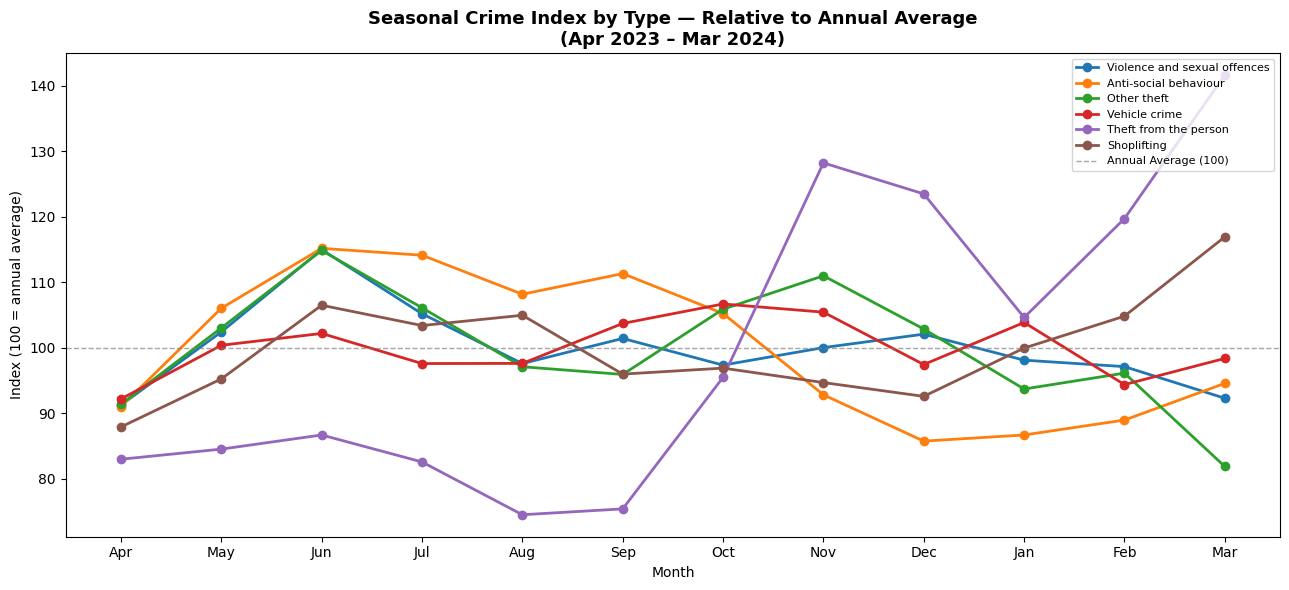

In [13]:
# ── Q8: Seasonal Patterns — monthly index per crime type ──────────────

# Extract month name for seasonal labelling
df['Month Name'] = df['Month'].dt.strftime('%b')
month_order = ['Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep',
               'Oct', 'Nov', 'Dec', 'Jan', 'Feb', 'Mar']

top_6 = df['Crime type'].value_counts().head(6).index.tolist()

seasonal = (
    df[df['Crime type'].isin(top_6)]
      .groupby(['Month Name', 'Crime type'])
      .size()
      .reset_index(name='Count')
)

# Normalise each crime type to its own 12-month average = 100
# So we see relative seasonal swing, not absolute volume
def index_to_average(group):
    group['Index'] = (group['Count'] / group['Count'].mean()) * 100
    return group

seasonal = seasonal.groupby('Crime type', group_keys=False).apply(index_to_average)
seasonal['Month Name'] = pd.Categorical(seasonal['Month Name'], categories=month_order, ordered=True)
seasonal = seasonal.sort_values('Month Name')

fig, ax = plt.subplots(figsize=(13, 6))

for crime in top_6:
    subset = seasonal[seasonal['Crime type'] == crime]
    ax.plot(subset['Month Name'], subset['Index'], marker='o', linewidth=2, label=crime)

ax.axhline(y=100, color='gray', linestyle='--', linewidth=1, alpha=0.7, label='Annual Average (100)')

ax.set_title('Seasonal Crime Index by Type — Relative to Annual Average\n(Apr 2023 – Mar 2024)',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Month')
ax.set_ylabel('Index (100 = annual average)')
ax.legend(loc='upper right', fontsize=8)

plt.tight_layout()
plt.savefig('seasonal_crime_index.png', dpi=150)
plt.show()

Theft from the person is the most volatile crime seasonally. It drops to index 75 in August
then surges to 129 in November as darker evenings and Christmas crowds create peak
pickpocketing conditions.

Anti-social behaviour peaks at index 115 in June and falls to 86 in December, consistent
with warmer months pushing activity outdoors. Shoplifting is flat for most of the year
but rises sharply in February and March, likely reflecting post-Christmas financial pressure.

The practical implication is that resources should not be distributed evenly across the
calendar. Theft from the person warrants higher coverage in autumn and winter while
anti-social behaviour patrols should be concentrated in summer.

# **SQL Analysis**

In [2]:
!pip install duckdb

In [3]:
import duckdb

# Connect to a local database file
con = duckdb.connect("/content/drive/MyDrive/london-crime-analysis/data/crime.db")

# Load the cleaned CSV directly into DuckDB as a table
con.execute("""
    CREATE TABLE IF NOT EXISTS crimes AS
    SELECT * FROM read_csv_auto(
        '/content/drive/MyDrive/london-crime-analysis/data/cleaned_crime_data.csv',
        header=True
    )
""")

result = con.execute("SELECT COUNT(*) as total_rows FROM crimes").fetchdf()
print(result)

# Check column names match
print(con.execute("DESCRIBE crimes").fetchdf())

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

   total_rows
0     1125295
             column_name column_type null   key default extra
0                  Month        DATE  YES  None    None  None
1              Longitude      DOUBLE  YES  None    None  None
2               Latitude      DOUBLE  YES  None    None  None
3               Location     VARCHAR  YES  None    None  None
4              LSOA code     VARCHAR  YES  None    None  None
5              LSOA name     VARCHAR  YES  None    None  None
6             Crime type     VARCHAR  YES  None    None  None
7  Last outcome category     VARCHAR  YES  None    None  None
8                Borough     VARCHAR  YES  None    None  None


# Query 1 - Total Crimes by Borough

In [4]:
q1 = con.execute("""
    SELECT
        Borough,
        COUNT(*) AS total_crimes
    FROM crimes
    GROUP BY Borough
    ORDER BY total_crimes DESC
""").fetchdf()

print(q1)

                   Borough  total_crimes
0              Westminster        103649
1                   Camden         49982
2                   Newham         48041
3            Tower Hamlets         46349
4                Southwark         45855
5                  Lambeth         45395
6                  Croydon         42020
7                   Ealing         41710
8                    Brent         41510
9                  Hackney         40008
10                 Enfield         36941
11               Islington         36860
12                Haringey         36727
13                  Barnet         36131
14                Lewisham         36018
15              Hillingdon         36000
16                Hounslow         34340
17              Wandsworth         33978
18               Greenwich         33856
19          Waltham Forest         30980
20               Redbridge         29719
21                 Bromley         28928
22  Kensington and Chelsea         27432
23  Hammersmith 

# Query 2 - Monthly Crime Trend

In [5]:
q2 = con.execute("""
    SELECT
        Month,
        COUNT(*) AS total_crimes
    FROM crimes
    GROUP BY Month
    ORDER BY Month
""").fetchdf()

print(q2)

        Month  total_crimes
0  2023-04-01         85220
1  2023-05-01         95094
2  2023-06-01        103750
3  2023-07-01         98143
4  2023-08-01         93156
5  2023-09-01         94959
6  2023-10-01         94752
7  2023-11-01         95682
8  2023-12-01         92253
9  2024-01-01         90399
10 2024-02-01         90538
11 2024-03-01         91349


# Query 3 - Top 5 Crime Types per Borough

In [7]:
q3 = con.execute("""
    SELECT
        Borough,
        "Crime type",
        COUNT(*) AS total_crimes,
        RANK() OVER (PARTITION BY Borough ORDER BY COUNT(*) DESC) AS rank
    FROM crimes
    GROUP BY Borough, "Crime type"
    QUALIFY rank <= 5
    ORDER BY Borough, rank
""").fetchdf()

print(q3)

                  Borough                    Crime type  total_crimes  rank
0    Barking and Dagenham  Violence and sexual offences          7526     1
1    Barking and Dagenham         Anti-social behaviour          4426     2
2    Barking and Dagenham                 Vehicle crime          2534     3
3    Barking and Dagenham                   Other theft          2136     4
4    Barking and Dagenham     Criminal damage and arson          1418     5
..                    ...                           ...           ...   ...
160           Westminster         Theft from the person         27140     1
161           Westminster                   Other theft         24156     2
162           Westminster         Anti-social behaviour         13141     3
163           Westminster  Violence and sexual offences         12362     4
164           Westminster                   Shoplifting          5406     5

[165 rows x 4 columns]


# Query 4 - Resolution Rate by Crime Type

In [8]:
q4 = con.execute("""
    SELECT
        "Crime type",
        COUNT(*) AS total_crimes,
        SUM(CASE WHEN "Last outcome category" NOT IN (
            'Investigation complete; no suspect identified',
            'Unable to prosecute suspect',
            'Not recorded'
        ) THEN 1 ELSE 0 END) AS resolved_crimes,
        ROUND(
            SUM(CASE WHEN "Last outcome category" NOT IN (
                'Investigation complete; no suspect identified',
                'Unable to prosecute suspect',
                'Not recorded'
            ) THEN 1 ELSE 0 END) * 100.0 / COUNT(*), 2
        ) AS resolution_rate_pct
    FROM crimes
    GROUP BY "Crime type"
    ORDER BY resolution_rate_pct DESC
""").fetchdf()

print(q4)

                      Crime type  total_crimes  resolved_crimes  \
0                          Drugs         34386          21404.0   
1          Possession of weapons          4854           2642.0   
2                    Other crime          9860           2692.0   
3   Violence and sexual offences        260509          43595.0   
4                   Public order         56259           7692.0   
5                    Shoplifting         60368           7411.0   
6                        Robbery         32527           3679.0   
7                       Burglary         54930           4867.0   
8      Criminal damage and arson         57100           4897.0   
9                    Other theft        129944           3955.0   
10         Theft from the person         77731           2288.0   
11                 Bicycle theft         15970            464.0   
12                 Vehicle crime        102353           2725.0   
13         Anti-social behaviour        228504              0.

## Query 3 — Top 5 Crime Types per Borough

The top crime profile varies significantly by borough type. Westminster is dominated by
Theft from the person (27,140) and Other theft (24,156), reflecting its role as a
high-footfall tourist and retail destination. Barking and Dagenham's top crime is
Violence and sexual offences (7,526), consistent with the EDA borough profile heatmap.
This confirms that boroughs need different policing strategies rather than a uniform
London-wide approach.

## Query 4 — Resolution Rate by Crime Type

Drugs offences resolve at 62.25% and possession of weapons at 54.43% because both are
typically caught in the act, requiring no further investigation. At the other end,
Anti-social behaviour resolves at 0% because it is not a criminal offence and therefore
cannot produce a criminal outcome by definition. Theft from the person (2.94%), bicycle
theft (2.91%) and vehicle crime (2.66%) all sit below 3%, reflecting how rarely
opportunistic crimes produce an identifiable suspect. Violence and sexual offences
resolves at 16.73% despite being the highest volume serious crime category.

# Query 5 - Monthly Trend by Crime Type

In [9]:
q5 = con.execute("""
    SELECT
        Month,
        "Crime type",
        COUNT(*) AS total_crimes
    FROM crimes
    GROUP BY Month, "Crime type"
    ORDER BY Month, total_crimes DESC
""").fetchdf()

print(q5)

         Month                    Crime type  total_crimes
0   2023-04-01  Violence and sexual offences         19815
1   2023-04-01         Anti-social behaviour         17330
2   2023-04-01                   Other theft          9897
3   2023-04-01                 Vehicle crime          7864
4   2023-04-01         Theft from the person          5376
..         ...                           ...           ...
163 2024-03-01                       Robbery          2740
164 2024-03-01                         Drugs          2587
165 2024-03-01                 Bicycle theft          1212
166 2024-03-01                   Other crime           740
167 2024-03-01         Possession of weapons           396

[168 rows x 3 columns]


# Query 6 - Resolution Rate by Borough

In [10]:
q6 = con.execute("""
    SELECT
        Borough,
        COUNT(*) AS total_crimes,
        SUM(CASE WHEN "Last outcome category" NOT IN (
            'Investigation complete; no suspect identified',
            'Unable to prosecute suspect',
            'Not recorded'
        ) THEN 1 ELSE 0 END) AS resolved_crimes,
        ROUND(
            SUM(CASE WHEN "Last outcome category" NOT IN (
                'Investigation complete; no suspect identified',
                'Unable to prosecute suspect',
                'Not recorded'
            ) THEN 1 ELSE 0 END) * 100.0 / COUNT(*), 2
        ) AS resolution_rate_pct
    FROM crimes
    GROUP BY Borough
    ORDER BY resolution_rate_pct DESC
""").fetchdf()

print(q6)

                   Borough  total_crimes  resolved_crimes  resolution_rate_pct
0           City of London          1426            318.0                22.30
1     Barking and Dagenham         24863           3065.0                12.33
2                 Havering         25431           3125.0                12.29
3                   Sutton         16056           1959.0                12.20
4                   Bexley         20038           2375.0                11.85
5                Greenwich         33856           3903.0                11.53
6                 Lewisham         36018           4094.0                11.37
7     Kingston upon Thames         14841           1678.0                11.31
8                   Newham         48041           5392.0                11.22
9                  Bromley         28928           3169.0                10.95
10                 Croydon         42020           4474.0                10.65
11          Waltham Forest         30980           3

## Query 5 — Monthly Trend by Crime Type

Violence and sexual offences and anti-social behaviour consistently rank as the top two
crime types every month across the full year. The SQL output confirms the seasonal
patterns identified in EDA - theft from the person volumes are notably lower in summer
months and rise sharply from October onward.

## Query 6 — Resolution Rate by Borough

City of London records the highest resolution rate at 22.30%, though with only 1,426
total crimes it is a statistical outlier with a dedicated specialist police force not
comparable to other boroughs. Among mainstream boroughs, Barking and Dagenham (12.33%),
Havering (12.29%) and Sutton (12.20%) lead on resolution.

Westminster sits at the bottom at 7.83% despite recording the highest crime volume in
London at 103,649 crimes. This is consistent with its crime profile being dominated by
theft from the person and other theft, which are among the lowest-resolving crime types
as identified in Query 4. Camden (7.93%) and Richmond upon Thames (8.07%) also sit near
the bottom, all three being boroughs with high tourist or transient footfall where
suspect identification is rarely possible.

# Query 7 - Cumulative Crime Total Over Time

In [11]:
q7 = con.execute("""
    SELECT
        Month,
        COUNT(*) AS monthly_crimes,
        SUM(COUNT(*)) OVER (ORDER BY Month) AS cumulative_crimes
    FROM crimes
    GROUP BY Month
    ORDER BY Month
""").fetchdf()

print(q7)

        Month  monthly_crimes  cumulative_crimes
0  2023-04-01           85220            85220.0
1  2023-05-01           95094           180314.0
2  2023-06-01          103750           284064.0
3  2023-07-01           98143           382207.0
4  2023-08-01           93156           475363.0
5  2023-09-01           94959           570322.0
6  2023-10-01           94752           665074.0
7  2023-11-01           95682           760756.0
8  2023-12-01           92253           853009.0
9  2024-01-01           90399           943408.0
10 2024-02-01           90538          1033946.0
11 2024-03-01           91349          1125295.0


# Query 8 - Borough Crime Concentration (Pareto)

In [12]:
q8 = con.execute("""
    SELECT
        Borough,
        total_crimes,
        ROUND(total_crimes * 100.0 / SUM(total_crimes) OVER (), 2) AS pct_of_london,
        ROUND(SUM(total_crimes) OVER (ORDER BY total_crimes DESC) * 100.0 /
              SUM(total_crimes) OVER (), 2) AS cumulative_pct
    FROM (
        SELECT Borough, COUNT(*) AS total_crimes
        FROM crimes
        GROUP BY Borough
    )
    ORDER BY total_crimes DESC
""").fetchdf()

print(q8)

                   Borough  total_crimes  pct_of_london  cumulative_pct
0              Westminster        103649           9.21            9.21
1                   Camden         49982           4.44           13.65
2                   Newham         48041           4.27           17.92
3            Tower Hamlets         46349           4.12           22.04
4                Southwark         45855           4.07           26.12
5                  Lambeth         45395           4.03           30.15
6                  Croydon         42020           3.73           33.88
7                   Ealing         41710           3.71           37.59
8                    Brent         41510           3.69           41.28
9                  Hackney         40008           3.56           44.83
10                 Enfield         36941           3.28           48.12
11               Islington         36860           3.28           51.39
12                Haringey         36727           3.26         

# Query 9 - Month over Month Change Using LAG

In [13]:
q9 = con.execute("""
    SELECT
        Month,
        monthly_crimes,
        LAG(monthly_crimes) OVER (ORDER BY Month) AS prev_month_crimes,
        monthly_crimes - LAG(monthly_crimes) OVER (ORDER BY Month) AS absolute_change,
        ROUND(
            (monthly_crimes - LAG(monthly_crimes) OVER (ORDER BY Month)) * 100.0 /
            LAG(monthly_crimes) OVER (ORDER BY Month), 2
        ) AS pct_change
    FROM (
        SELECT Month, COUNT(*) AS monthly_crimes
        FROM crimes
        GROUP BY Month
    )
    ORDER BY Month
""").fetchdf()

print(q9)

        Month  monthly_crimes  prev_month_crimes  absolute_change  pct_change
0  2023-04-01           85220               <NA>             <NA>         NaN
1  2023-05-01           95094              85220             9874       11.59
2  2023-06-01          103750              95094             8656        9.10
3  2023-07-01           98143             103750            -5607       -5.40
4  2023-08-01           93156              98143            -4987       -5.08
5  2023-09-01           94959              93156             1803        1.94
6  2023-10-01           94752              94959             -207       -0.22
7  2023-11-01           95682              94752              930        0.98
8  2023-12-01           92253              95682            -3429       -3.58
9  2024-01-01           90399              92253            -1854       -2.01
10 2024-02-01           90538              90399              139        0.15
11 2024-03-01           91349              90538              81

# Query 10 - Highest Volume, Lowest Resolution per Borough

In [14]:
q10 = con.execute("""
    SELECT
        Borough,
        "Crime type",
        total_crimes,
        resolution_rate_pct,
        RANK() OVER (PARTITION BY Borough ORDER BY total_crimes DESC) AS volume_rank,
        RANK() OVER (PARTITION BY Borough ORDER BY resolution_rate_pct ASC) AS worst_resolution_rank
    FROM (
        SELECT
            Borough,
            "Crime type",
            COUNT(*) AS total_crimes,
            ROUND(SUM(CASE WHEN "Last outcome category" NOT IN (
                'Investigation complete; no suspect identified',
                'Unable to prosecute suspect',
                'Not recorded'
            ) THEN 1 ELSE 0 END) * 100.0 / COUNT(*), 2) AS resolution_rate_pct
        FROM crimes
        GROUP BY Borough, "Crime type"
    )
    QUALIFY volume_rank <= 3 AND worst_resolution_rank <= 3
    ORDER BY Borough, total_crimes DESC
""").fetchdf()

print(q10)

                   Borough             Crime type  total_crimes  \
0     Barking and Dagenham  Anti-social behaviour          4426   
1                   Barnet  Anti-social behaviour          8306   
2                   Barnet          Vehicle crime          4531   
3                   Bexley  Anti-social behaviour          3657   
4                    Brent  Anti-social behaviour          9813   
5                    Brent          Vehicle crime          3955   
6                  Bromley  Anti-social behaviour          5438   
7                  Bromley          Vehicle crime          3349   
8                   Camden  Anti-social behaviour          9945   
9                  Croydon  Anti-social behaviour          8256   
10                 Croydon          Vehicle crime          4034   
11                  Ealing  Anti-social behaviour         10143   
12                  Ealing          Vehicle crime          4826   
13                 Enfield  Anti-social behaviour          822

## Query 7 — Cumulative Crime Total

The cumulative total reaches exactly 1,125,295 by March 2024, confirming full data
integrity across all 12 months. Crime volume climbed steeply through spring into a
June peak of 103,750 before declining gradually through winter. By September 2023
over half the year's total crime had already been recorded.

## Query 8 — Borough Crime Concentration (Pareto Analysis)

Westminster alone accounts for 9.21% of all London crime. Just 12 boroughs from
Westminster to Islington account for over 50% of all recorded crime in London,
while the bottom 4 boroughs (Sutton, Richmond upon Thames, Kingston upon Thames and
City of London) collectively account for under 4%. This is a textbook Pareto
distribution — a small number of boroughs carry a disproportionate share of the
total burden, which has direct implications for how policing resources should be
allocated geographically.

## Query 9 — Month over Month Change

The sharpest rise occurred between April and May 2023 (+11.59%) and May to June
(+9.10%), driven by the summer surge in anti-social behaviour and violence. The
steepest single-month drop was June to July (-5.40%) as the peak subsided. The
second half of the year is notably stable, with monthly changes staying within 4%
in either direction, suggesting crime volume in London follows a predictable
seasonal rhythm rather than random fluctuation.

## Query 10 — High Volume, Low Resolution by Borough

Anti-social behaviour appears across virtually every borough as simultaneously
high volume and 0% resolution rate. This is structurally expected — ASB is not a
criminal offence and cannot produce a criminal outcome. More concerning is vehicle
crime appearing consistently as a top-three volume crime with resolution rates
between 1.8% and 2.84% across boroughs. Westminster's Other theft category is
the starkest single finding — 24,156 crimes recorded with just 2.24% resolution,
representing over 23,500 crimes in one borough in one year with no outcome.

# Borough Crime Profile Matrix

In [15]:
# ── Step 4a: Borough Crime Profile Matrix ─────────────────────────────
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Calculate crime type counts per borough
borough_crime = (
    df.groupby(['Borough', 'Crime type'])
      .size()
      .reset_index(name='Count')
)

# Pivot to borough × crime type matrix
profile_matrix = borough_crime.pivot(
    index='Borough',
    columns='Crime type',
    values='Count'
).fillna(0)

# Convert counts to percentages (row-wise normalisation)
profile_pct = profile_matrix.div(profile_matrix.sum(axis=1), axis=0) * 100

print("Matrix shape:", profile_pct.shape)
print("\nFirst few rows:")
print(profile_pct.round(2).head())

Matrix shape: (33, 14)

First few rows:
Crime type            Anti-social behaviour  Bicycle theft  Burglary  \
Borough                                                                
Barking and Dagenham                  17.80           0.47      4.19   
Barnet                                22.99           0.50      6.57   
Bexley                                18.25           0.32      4.72   
Brent                                 23.64           0.77      5.21   
Bromley                               18.80           0.45      5.12   

Crime type            Criminal damage and arson  Drugs  Other crime  \
Borough                                                               
Barking and Dagenham                       5.70   4.62         0.99   
Barnet                                     5.12   2.80         0.90   
Bexley                                     8.06   3.18         1.10   
Brent                                      5.17   3.61         0.76   
Bromley                      

# Scale the Data

In [16]:
# ── Scale the Data ───────────────────────────────────────────

scaler = StandardScaler()
profile_scaled = scaler.fit_transform(profile_pct)

print("Scaling complete.")
print(f"Shape: {profile_scaled.shape}")
print(f"Mean of first column after scaling: {profile_scaled[:, 0].mean():.4f}")
print(f"Std of first column after scaling: {profile_scaled[:, 0].std():.4f}")
# Mean should be ~0 and std should be ~1 — confirms scaling worked correctly

Scaling complete.
Shape: (33, 14)
Mean of first column after scaling: -0.0000
Std of first column after scaling: 1.0000


# Elbow Method

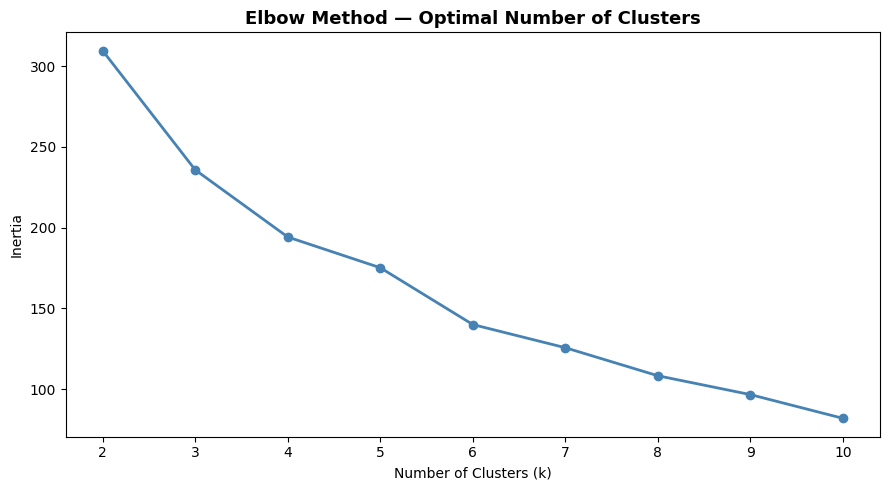


Inertia values:
  k=2: 309.50
  k=3: 235.72
  k=4: 194.15
  k=5: 175.11
  k=6: 139.93
  k=7: 125.59
  k=8: 108.22
  k=9: 96.55
  k=10: 81.86


In [17]:
# ── Elbow Method ─────────────────────────────────────────────

inertia = []
k_range = range(2, 11)

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(profile_scaled)
    inertia.append(kmeans.inertia_)

fig, ax = plt.subplots(figsize=(9, 5))

ax.plot(k_range, inertia, marker='o', linewidth=2, color='steelblue')
ax.set_title('Elbow Method — Optimal Number of Clusters', fontsize=13, fontweight='bold')
ax.set_xlabel('Number of Clusters (k)')
ax.set_ylabel('Inertia')
ax.set_xticks(k_range)

plt.tight_layout()
plt.savefig('elbow_plot.png', dpi=150)
plt.show()

print("\nInertia values:")
for k, val in zip(k_range, inertia):
    print(f"  k={k}: {val:.2f}")

# K means Clustering

In [18]:
# ── Run K-Means ──────────────────────────────────────────────

kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
kmeans.fit(profile_scaled)

# Assign cluster labels back to the profile matrix
profile_pct['Cluster'] = kmeans.labels_

# See which boroughs landed in each cluster
for cluster in sorted(profile_pct['Cluster'].unique()):
    boroughs = profile_pct[profile_pct['Cluster'] == cluster].index.tolist()
    print(f"\nCluster {cluster} ({len(boroughs)} boroughs):")
    print(boroughs)


Cluster 0 (11 boroughs):
['Barking and Dagenham', 'Bexley', 'Bromley', 'Croydon', 'Greenwich', 'Havering', 'Hillingdon', 'Kingston upon Thames', 'Lewisham', 'Merton', 'Sutton']

Cluster 1 (11 boroughs):
['Barnet', 'Brent', 'Ealing', 'Enfield', 'Hammersmith and Fulham', 'Harrow', 'Hounslow', 'Redbridge', 'Richmond upon Thames', 'Waltham Forest', 'Wandsworth']

Cluster 2 (2 boroughs):
['City of London', 'Westminster']

Cluster 3 (9 boroughs):
['Camden', 'Hackney', 'Haringey', 'Islington', 'Kensington and Chelsea', 'Lambeth', 'Newham', 'Southwark', 'Tower Hamlets']


In [19]:
# ── Cluster profile summary — what defines each cluster ───────────────

cluster_summary = (
    profile_pct.groupby('Cluster')
               .mean()
               .round(2)
)

print(cluster_summary.T)
# Transposed so crime types are rows and clusters are columns
# Makes it much easier to see what each cluster is dominated by

Cluster                           0      1      2      3
Crime type                                              
Anti-social behaviour         19.51  22.54   8.62  20.87
Bicycle theft                  0.92   1.57   2.02   2.01
Burglary                       4.79   5.65   2.78   4.98
Criminal damage and arson      6.61   5.36   2.78   4.46
Drugs                          3.43   2.90   1.58   3.06
Other crime                    1.28   0.86   0.33   0.66
Other theft                    8.46   9.17  30.45  12.85
Possession of weapons          0.51   0.37   0.17   0.43
Public order                   5.56   5.19   3.49   4.83
Robbery                        2.26   2.30   3.77   3.53
Shoplifting                    6.88   5.27   6.22   4.48
Theft from the person          2.09   2.80  22.52   8.97
Vehicle crime                  9.86  11.54   3.21   7.77
Violence and sexual offences  27.86  24.49  12.06  21.12


In [20]:
# ── Assign cluster names ───────────────────────────

cluster_names = {
    0: 'Outer Suburban — Violence Dominant',
    1: 'Residential Outer — ASB and Vehicle Crime',
    2: 'Commercial and Tourist Centres — Theft Dominant',
    3: 'Inner City — Mixed High Density Crime'
}

profile_pct['Cluster Label'] = profile_pct['Cluster'].map(cluster_names)

print(profile_pct[['Cluster', 'Cluster Label']].drop_duplicates().sort_values('Cluster'))

Crime type            Cluster                                    Cluster Label
Borough                                                                       
Barking and Dagenham        0               Outer Suburban — Violence Dominant
Barnet                      1        Residential Outer — ASB and Vehicle Crime
City of London              2  Commercial and Tourist Centres — Theft Dominant
Camden                      3            Inner City — Mixed High Density Crime


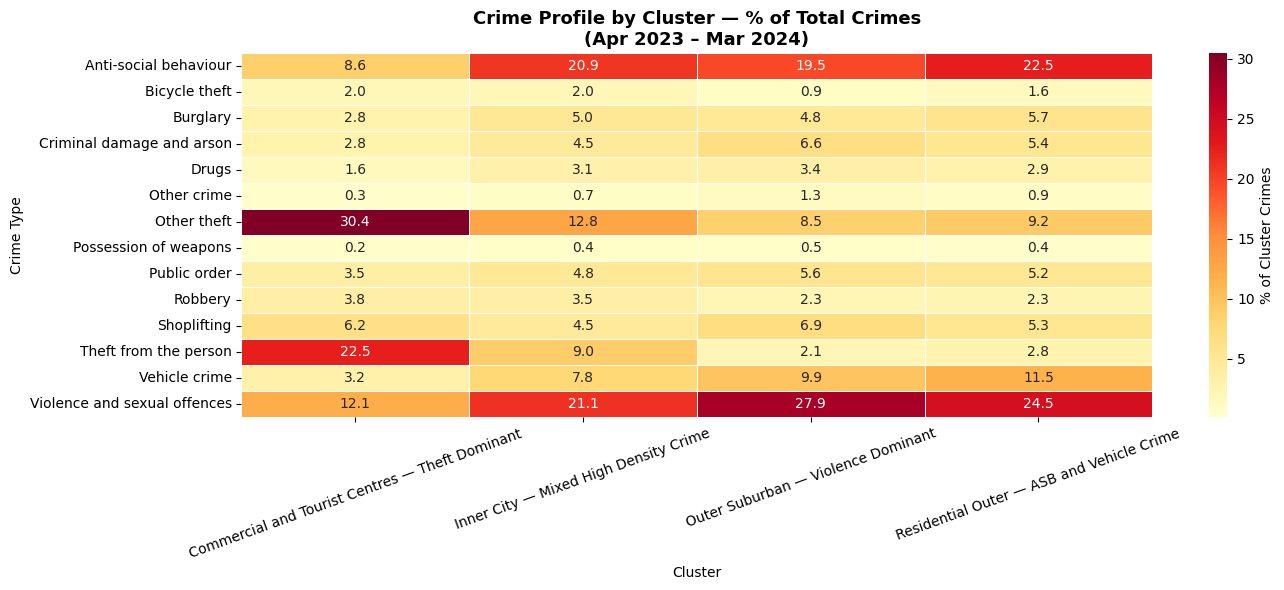

In [21]:
# ── Heatmap of cluster crime profiles ────────────────────────

cluster_profile = (
    profile_pct.groupby('Cluster Label')
               .mean()
               .drop(columns=['Cluster'])
               .round(2)
)

fig, ax = plt.subplots(figsize=(14, 6))

sns.heatmap(
    cluster_profile.T,
    annot=True,
    fmt='.1f',
    cmap='YlOrRd',
    linewidths=0.4,
    ax=ax,
    cbar_kws={'label': '% of Cluster Crimes'}
)

ax.set_title('Crime Profile by Cluster — % of Total Crimes\n(Apr 2023 – Mar 2024)',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Cluster')
ax.set_ylabel('Crime Type')
ax.tick_params(axis='x', rotation=20)
ax.tick_params(axis='y', rotation=0)

plt.tight_layout()
plt.savefig('cluster_profile_heatmap.png', dpi=150)
plt.show()

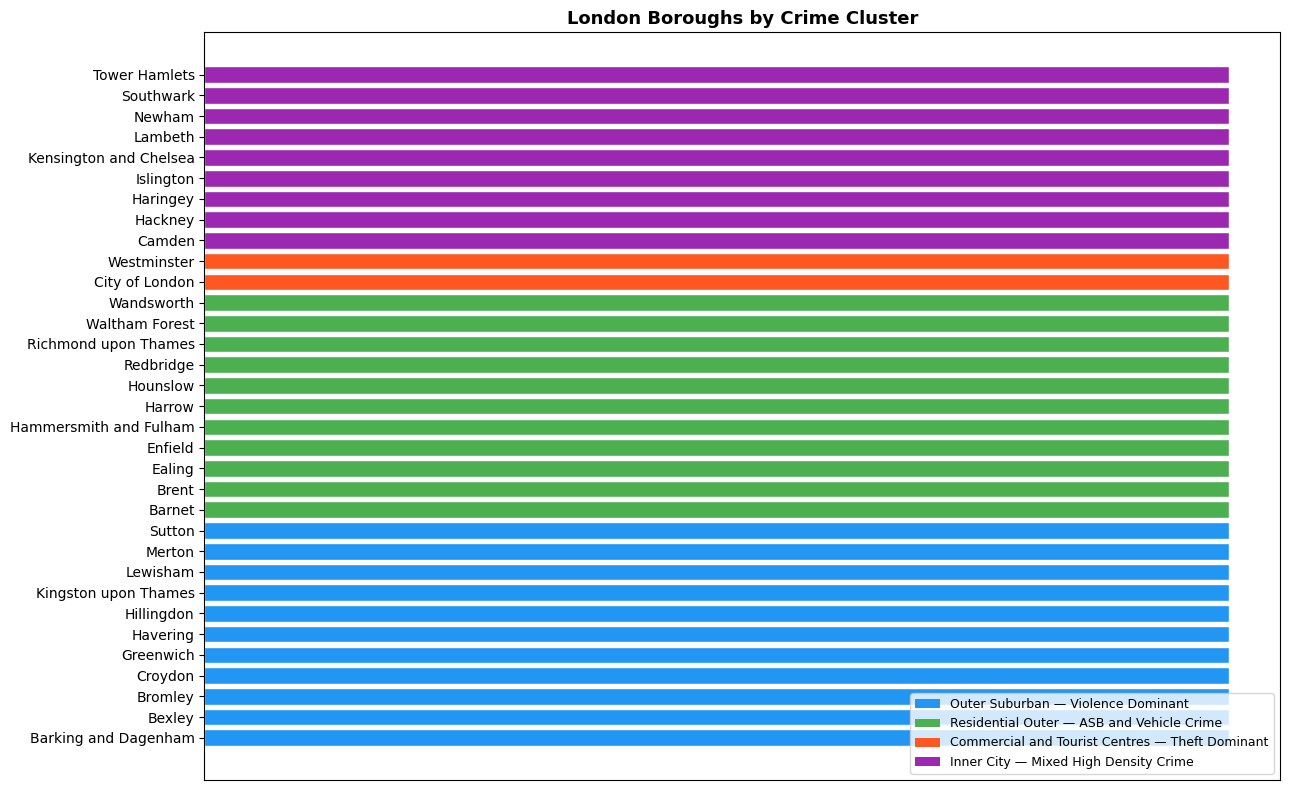

In [22]:
# ── Bar chart - boroughs by cluster ──────────────────────────

borough_clusters = profile_pct[['Cluster', 'Cluster Label']].reset_index()
borough_clusters = borough_clusters.sort_values(['Cluster', 'Borough'])

colors = {
    'Outer Suburban — Violence Dominant': '#2196F3',
    'Residential Outer — ASB and Vehicle Crime': '#4CAF50',
    'Commercial and Tourist Centres — Theft Dominant': '#FF5722',
    'Inner City — Mixed High Density Crime': '#9C27B0'
}

fig, ax = plt.subplots(figsize=(13, 8))

for i, (_, row) in enumerate(borough_clusters.iterrows()):
    ax.barh(row['Borough'], 1,
            color=colors[row['Cluster Label']],
            edgecolor='white')

from matplotlib.patches import Patch
legend_elements = [Patch(facecolor=v, label=k) for k, v in colors.items()]
ax.legend(handles=legend_elements, loc='lower right', fontsize=9)

ax.set_title('London Boroughs by Crime Cluster', fontsize=13, fontweight='bold')
ax.set_xlabel('')
ax.set_xticks([])

plt.tight_layout()
plt.savefig('borough_cluster_assignments.png', dpi=150)
plt.show()

## K-Means Clustering

### Methodology
Each of the 33 London boroughs was represented as a vector of 14 crime type percentages
— what proportion of that borough's total crimes fell into each category. StandardScaler
was applied before clustering to ensure no single crime type dominated due to scale
differences. The elbow method was used to select k=4 as the optimal cluster count,
where the rate of inertia improvement dropped most noticeably.

### Cluster Profiles

**Cluster 0 — Outer Suburban, Violence Dominant (11 boroughs)**
Barking and Dagenham, Bexley, Bromley, Croydon, Greenwich, Havering, Hillingdon,
Kingston upon Thames, Lewisham, Merton and Sutton. Violence and sexual offences
account for 27.9% of crimes — the highest of any cluster. Vehicle crime is also
elevated at 9.9%. These are outer residential boroughs where interpersonal violence
rather than opportunistic theft defines the crime landscape.

**Cluster 1 — Residential Outer, ASB and Vehicle Crime (11 boroughs)**
Barnet, Brent, Ealing, Enfield, Hammersmith and Fulham, Harrow, Hounslow, Redbridge,
Richmond upon Thames, Waltham Forest and Wandsworth. The highest ASB proportion at
22.5% and highest vehicle crime at 11.5% across all clusters. Large housing stock
and residential density drive both categories.

**Cluster 2 — Commercial and Tourist Centres, Theft Dominant (2 boroughs)**
Westminster and City of London. Over half of all crime is theft — Other theft at
30.4% and Theft from the person at 22.5%. Violence and ASB are proportionally
very low at 12.1% and 8.6% respectively. These two boroughs are analytically
distinct from every other borough in London and require an entirely different
policing approach centred on public space and transit theft prevention.

**Cluster 3 — Inner City, Mixed High Density Crime (9 boroughs)**
Camden, Hackney, Haringey, Islington, Kensington and Chelsea, Lambeth, Newham,
Southwark and Tower Hamlets. No single crime type dominates — violence at 21.1%,
ASB at 20.9% and Other theft at 12.8% are all elevated simultaneously. These
boroughs face layered, overlapping crime challenges that resist single-category
intervention strategies.

# Install and Run Prophet

In [23]:
!pip install prophet --quiet

In [24]:
from prophet import Prophet

# ── Prepare cluster-level monthly totals ─────────────────────────────

# Merge cluster labels back onto main dataframe
cluster_lookup = profile_pct[['Cluster Label']].reset_index()
df_clustered = df.merge(cluster_lookup, on='Borough', how='left')

# Aggregate monthly crime counts per cluster
cluster_monthly = (
    df_clustered.groupby(['Cluster Label', 'Month'])
                .size()
                .reset_index(name='Crime Count')
)

print(cluster_monthly.head(12))

                                      Cluster Label      Month  Crime Count
0   Commercial and Tourist Centres — Theft Dominant 2023-04-01         7561
1   Commercial and Tourist Centres — Theft Dominant 2023-05-01         8176
2   Commercial and Tourist Centres — Theft Dominant 2023-06-01         8784
3   Commercial and Tourist Centres — Theft Dominant 2023-07-01         8634
4   Commercial and Tourist Centres — Theft Dominant 2023-08-01         7822
5   Commercial and Tourist Centres — Theft Dominant 2023-09-01         7694
6   Commercial and Tourist Centres — Theft Dominant 2023-10-01         8888
7   Commercial and Tourist Centres — Theft Dominant 2023-11-01        10615
8   Commercial and Tourist Centres — Theft Dominant 2023-12-01        10567
9   Commercial and Tourist Centres — Theft Dominant 2024-01-01         8594
10  Commercial and Tourist Centres — Theft Dominant 2024-02-01         8962
11  Commercial and Tourist Centres — Theft Dominant 2024-03-01         8778


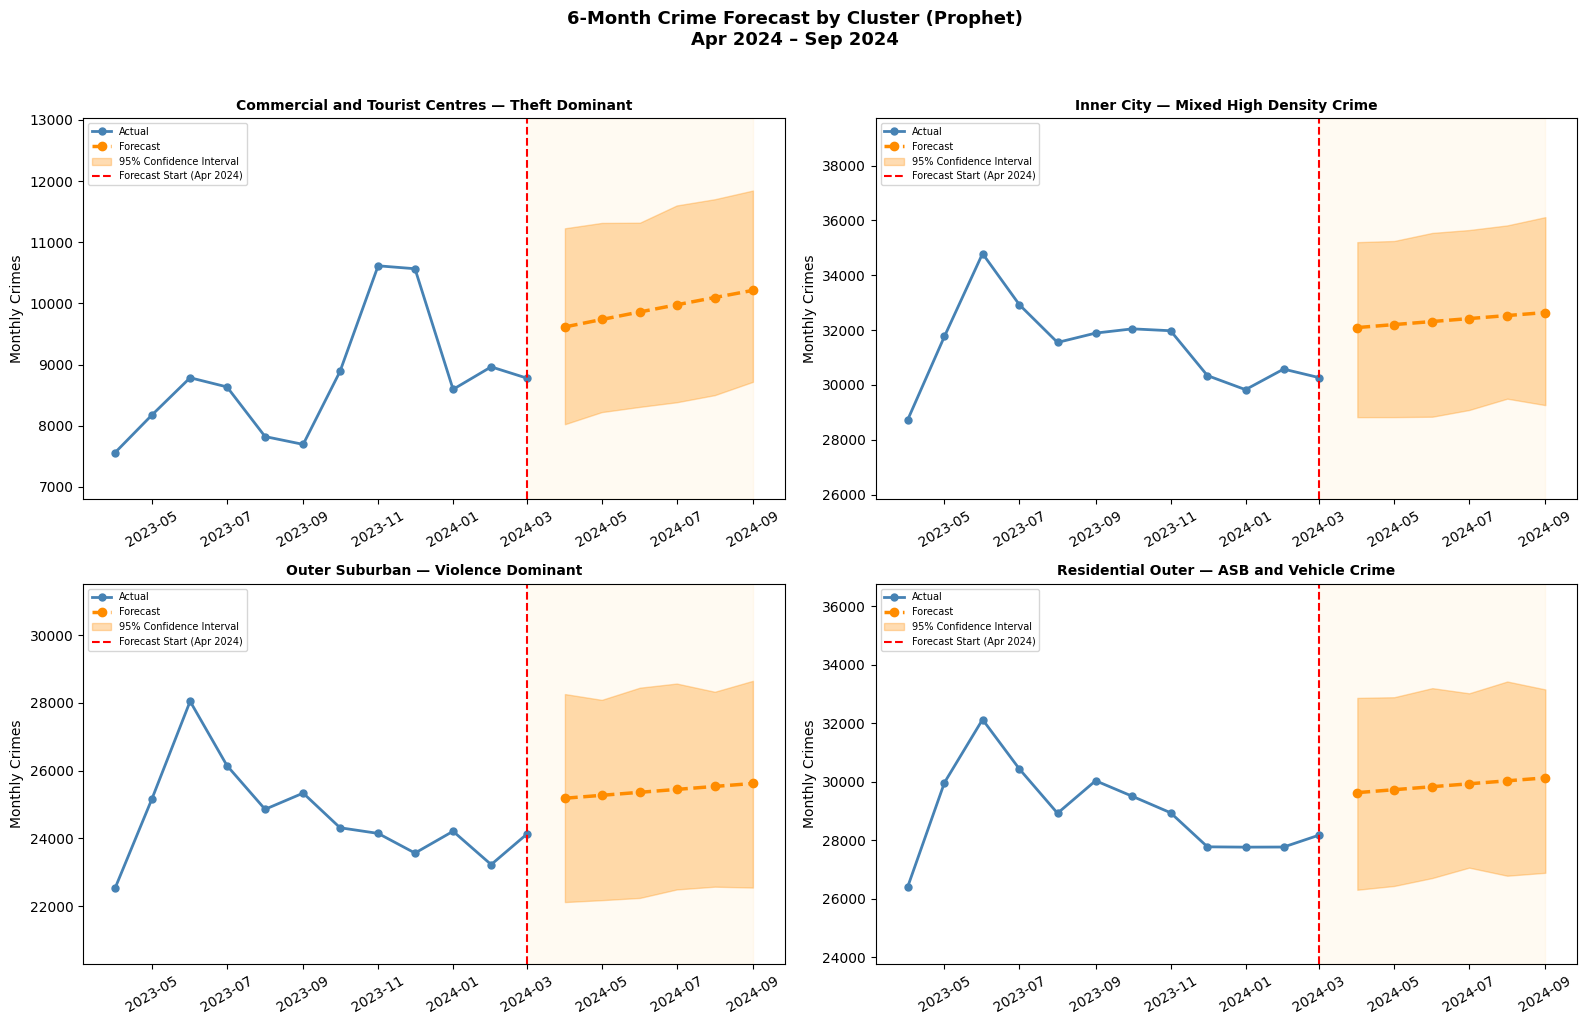

Forecast Summary — Apr to Sep 2024

Cluster                                            Month             Forecast      Lower      Upper
----------------------------------------------------------------------------------------------------
Commercial and Tourist Centres — Theft Dominant    2024-04-01            9615       8024      11228
Commercial and Tourist Centres — Theft Dominant    2024-05-01            9737       8222      11316
Commercial and Tourist Centres — Theft Dominant    2024-06-01            9860       8307      11320
Commercial and Tourist Centres — Theft Dominant    2024-07-01            9977       8383      11602
Commercial and Tourist Centres — Theft Dominant    2024-08-01           10096       8499      11704
Commercial and Tourist Centres — Theft Dominant    2024-09-01           10213       8717      11846

Inner City — Mixed High Density Crime              2024-04-01           32090      28822      35205
Inner City — Mixed High Density Crime              2024-05-01 

In [33]:
from prophet import Prophet
import warnings
warnings.filterwarnings('ignore')

forecast_results = {}
cluster_labels = sorted(cluster_monthly['Cluster Label'].unique())

# ── Fit Prophet model for each cluster ───────────────────────────────

for cluster in cluster_labels:
    cluster_data = (
        cluster_monthly[cluster_monthly['Cluster Label'] == cluster]
        [['Month', 'Crime Count']]
        .rename(columns={'Month': 'ds', 'Crime Count': 'y'})
    )

    cluster_data['floor'] = 0
    cluster_data['cap'] = cluster_data['y'].max() * 1.3

    model = Prophet(
        growth='logistic',
        yearly_seasonality=False,
        weekly_seasonality=False,
        daily_seasonality=False,
        n_changepoints=3,
        changepoint_prior_scale=0.05,
        interval_width=0.95
    )
    model.fit(cluster_data)

    future = model.make_future_dataframe(periods=6, freq='MS')
    future['floor'] = 0
    future['cap'] = cluster_data['cap'].iloc[0]

    forecast = model.predict(future)
    forecast_results[cluster] = forecast


# ── Plot ──────────────────────────────────────────────────────────────

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
axes = axes.flatten()

for i, cluster in enumerate(cluster_labels):

    cluster_data = (
        cluster_monthly[cluster_monthly['Cluster Label'] == cluster]
        [['Month', 'Crime Count']]
        .rename(columns={'Month': 'ds', 'Crime Count': 'y'})
    )

    forecast = forecast_results[cluster]
    future_forecast = forecast[forecast['ds'] > '2024-03-01']

    ax = axes[i]

    ax.plot(cluster_data['ds'], cluster_data['y'],
            'o-', color='steelblue', linewidth=2, label='Actual', markersize=5)

    ax.plot(future_forecast['ds'], future_forecast['yhat'],
            'o--', color='darkorange', linewidth=2.5,
            markersize=6, label='Forecast')

    ax.fill_between(future_forecast['ds'],
                    future_forecast['yhat_lower'].clip(lower=0),
                    future_forecast['yhat_upper'],
                    alpha=0.3, color='darkorange', label='95% Confidence Interval')

    last_actual = cluster_data['ds'].max()
    ax.axvline(x=last_actual, color='red',
               linestyle='--', linewidth=1.5, label='Forecast Start (Apr 2024)')

    ax.axvspan(last_actual, future_forecast['ds'].max(),
               alpha=0.05, color='orange')

    all_values = list(cluster_data['y']) + list(future_forecast['yhat'])
    y_min = min(all_values) * 0.90
    y_max = max(list(future_forecast['yhat_upper']) + list(cluster_data['y'])) * 1.10
    ax.set_ylim(bottom=max(0, y_min), top=y_max)

    ax.set_title(cluster, fontsize=10, fontweight='bold')
    ax.set_xlabel('')
    ax.set_ylabel('Monthly Crimes')
    ax.legend(fontsize=7)
    ax.tick_params(axis='x', rotation=30)

plt.suptitle('6-Month Crime Forecast by Cluster (Prophet)\nApr 2024 – Sep 2024',
             fontsize=13, fontweight='bold', y=1.02)

plt.tight_layout()
plt.savefig('prophet_forecast_by_cluster.png', dpi=150, bbox_inches='tight')
plt.show()


# ── Forecast summary table ────────────────────────────────────────────

print("Forecast Summary — Apr to Sep 2024\n")
print(f"{'Cluster':<50} {'Month':<15} {'Forecast':>10} {'Lower':>10} {'Upper':>10}")
print("-" * 100)

for cluster in cluster_labels:
    forecast = forecast_results[cluster]
    future_only = forecast[forecast['ds'] > '2024-03-01'][
        ['ds', 'yhat', 'yhat_lower', 'yhat_upper']
    ].head(6)
    for _, row in future_only.iterrows():
        print(f"{cluster:<50} {str(row['ds'])[:10]:<15} "
              f"{max(0, row['yhat']):>10.0f} "
              f"{max(0, row['yhat_lower']):>10.0f} "
              f"{max(0, row['yhat_upper']):>10.0f}")
    print()

In [34]:
# ── Full cleaned dataset with cluster labels ────────────────

df_clustered['Cluster Label'] = df_clustered['Cluster Label'].astype(str)

df_clustered.to_csv(
    "/content/drive/MyDrive/london-crime-analysis/data/crime_with_clusters.csv",
    index=False
)

print(f"Exported: {len(df_clustered):,} rows")
print(f"Columns: {df_clustered.columns.tolist()}")

Exported: 1,125,295 rows
Columns: ['Month', 'Longitude', 'Latitude', 'Location', 'LSOA code', 'LSOA name', 'Crime type', 'Last outcome category', 'Borough', 'Cluster Label']


In [39]:
# ── Borough cluster summary table ───────────────────────────

borough_summary = (
    df_clustered.groupby(['Borough', 'Cluster Label'])
                .agg(total_crimes=('Crime type', 'count'))
                .reset_index()
)

# Add resolution rate per borough
resolution = (
    df_clustered.groupby('Borough')
                .apply(lambda x: round(
                    x['Outcome Group'].eq('Resolved').sum() / len(x) * 100, 2
                ))
                .reset_index()
)
resolution.columns = ['Borough', 'Resolution Rate (%)']

borough_summary = borough_summary.merge(resolution, on='Borough')

borough_summary.to_csv(
    "/content/drive/MyDrive/london-crime-analysis/data/borough_summary.csv",
    index=False
)

print(borough_summary)

                   Borough                                    Cluster Label  \
0     Barking and Dagenham               Outer Suburban — Violence Dominant   
1                   Barnet        Residential Outer — ASB and Vehicle Crime   
2                   Bexley               Outer Suburban — Violence Dominant   
3                    Brent        Residential Outer — ASB and Vehicle Crime   
4                  Bromley               Outer Suburban — Violence Dominant   
5                   Camden            Inner City — Mixed High Density Crime   
6           City of London  Commercial and Tourist Centres — Theft Dominant   
7                  Croydon               Outer Suburban — Violence Dominant   
8                   Ealing        Residential Outer — ASB and Vehicle Crime   
9                  Enfield        Residential Outer — ASB and Vehicle Crime   
10               Greenwich               Outer Suburban — Violence Dominant   
11                 Hackney            Inner City — M

In [40]:
# ── Monthly crime totals by cluster ─────────────────────────

cluster_monthly.to_csv(
    "/content/drive/MyDrive/london-crime-analysis/data/cluster_monthly.csv",
    index=False
)

print(cluster_monthly.head())

                                     Cluster Label      Month  Crime Count
0  Commercial and Tourist Centres — Theft Dominant 2023-04-01         7561
1  Commercial and Tourist Centres — Theft Dominant 2023-05-01         8176
2  Commercial and Tourist Centres — Theft Dominant 2023-06-01         8784
3  Commercial and Tourist Centres — Theft Dominant 2023-07-01         8634
4  Commercial and Tourist Centres — Theft Dominant 2023-08-01         7822
